# S&P 500 Prediction with Price, Volume, and Article Features

This notebook builds an end-to-end machine learning workflow for two related stock prediction tasks:

- **5-Day Top-vs-Bottom Cross-Sectional Classification**: the primary task, focused on identifying relative winners and losers over the next five trading days.
- **Next-Day Direction Prediction**: a harder comparison task, focused on predicting whether the next close is higher than the current close.

All data preparation, feature engineering, tuning, plots, validation results, and final test results are computed inside this notebook.

## 1. Read and Inspect the Data

The raw data is a daily stock panel. Each row is a `(date, ticker)` observation with price/volume fields, company metadata, and aggregated article/sentiment features.

In [ ]:
from pathlib import Path
import ast
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError:
    torch = None

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

DATA_PATH = Path("sp500_panel_with_sentiment.csv")
raw = pd.read_csv(DATA_PATH, parse_dates=["date"])

print(f"Shape: {raw.shape}")
print(f"Date range: {raw['date'].min().date()} to {raw['date'].max().date()}")
print(f"Tickers: {raw['ticker'].nunique()}")
print(f"Duplicate (date, ticker) rows: {raw.duplicated(['date', 'ticker']).sum()}")
display(raw.dtypes.to_frame("dtype").T)
display(raw.head())

Shape: (515715, 17)
Date range: 2022-01-03 to 2026-02-13
Tickers: 503
Duplicate (date, ticker) rows: 0


,date,ticker,close,high,low,open,volume,company,sector,industry,article_count,pos_prob_mean,neg_prob_mean,neu_prob_mean,positive_count,negative_count,neutral_count
dtype,datetime64[ns],object,float64,float64,float64,float64,float64,object,object,object,int64,float64,float64,float64,float64,float64,float64


,date,ticker,close,high,low,open,volume,company,sector,industry,article_count,pos_prob_mean,neg_prob_mean,neu_prob_mean,positive_count,negative_count,neutral_count
0,2022-01-03,A,152.048294,154.924470,149.570510,154.496929,1606300.0,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-04,A,146.908142,151.222399,145.460335,151.086365,2234000.0,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-05,A,144.391479,148.764034,144.323455,146.558319,2370500.0,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-06,A,144.896744,145.712965,141.457007,144.634401,2298300.0,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-07,A,141.039185,145.489476,140.980886,144.896751,2058600.0,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,0,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
missing = raw.isna().sum().to_frame("missing_rows")
missing["missing_pct"] = missing["missing_rows"] / len(raw)
display(missing[missing["missing_rows"] > 0].sort_values("missing_rows", ascending=False))

sentiment_cols = [
    "pos_prob_mean", "neg_prob_mean", "neu_prob_mean",
    "positive_count", "negative_count", "neutral_count",
]
no_articles = raw["article_count"].eq(0)
all_sentiment_missing = raw[sentiment_cols].isna().all(axis=1)
print(f"Rows with no articles: {no_articles.sum():,} ({no_articles.mean():.1%})")
print(f"No-article rows where all sentiment fields are missing: {(no_articles & all_sentiment_missing).sum():,}")

,missing_rows,missing_pct
pos_prob_mean,395045,0.766014
neg_prob_mean,395045,0.766014
neu_prob_mean,395045,0.766014
positive_count,395045,0.766014
negative_count,395045,0.766014
neutral_count,395045,0.766014


Rows with no articles: 395,045 (76.6%)
No-article rows where all sentiment fields are missing: 395,045


Sentiment sparsity is best understood as article availability. When there are no articles for a stock on a date, the sentiment aggregates are unavailable. The modeling workflow keeps those rows and represents article availability with engineered features.

## 2. Exploratory Data Analysis

The EDA focuses on article coverage, sector composition, and class balance. These checks motivate using the Information Technology sector as the final modeling dataset while keeping all trading days.

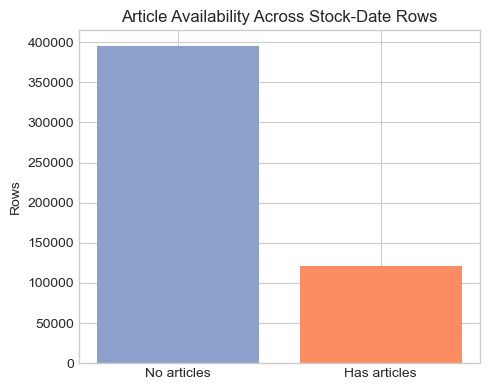

,rows,article_coverage
sector,,
Energy,22726,0.337543
Communication Services,23759,0.271855
Information Technology,70572,0.268974
Consumer Staples,36853,0.257862
Consumer Discretionary,49584,0.245361
Financials,77474,0.225663
Health Care,61181,0.224187
Industrials,80607,0.212054
Utilities,32012,0.207329


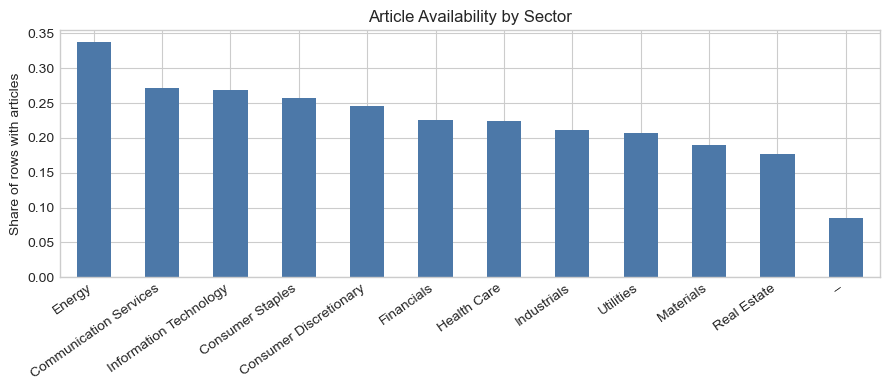

In [3]:
coverage_counts = pd.Series({
    "No articles": int(raw["article_count"].eq(0).sum()),
    "Has articles": int(raw["article_count"].gt(0).sum()),
})

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(coverage_counts.index, coverage_counts.values, color=["#8da0cb", "#fc8d62"])
ax.set_title("Article Availability Across Stock-Date Rows")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.show()

sector_coverage = (
    raw.assign(has_articles=raw["article_count"].gt(0))
    .groupby("sector")
    .agg(rows=("ticker", "size"), article_coverage=("has_articles", "mean"))
    .sort_values("article_coverage", ascending=False)
)
display(sector_coverage)

fig, ax = plt.subplots(figsize=(9, 4))
sector_coverage["article_coverage"].plot(kind="bar", ax=ax, color="#4c78a8")
ax.set_title("Article Availability by Sector")
ax.set_ylabel("Share of rows with articles")
ax.set_xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

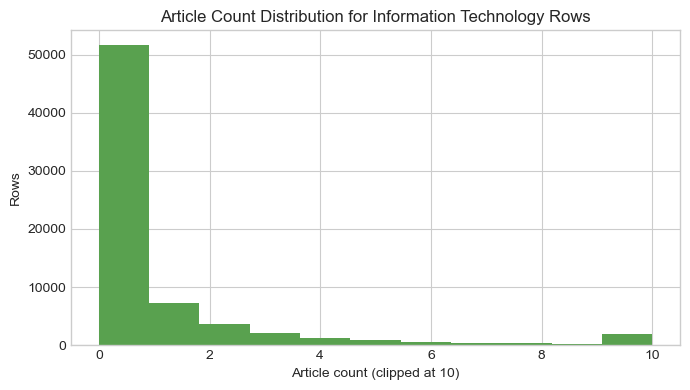

Information Technology rows: 70,572
Information Technology article availability: 26.9%


In [4]:
tech_raw = raw[raw["sector"].eq("Information Technology")]

fig, ax = plt.subplots(figsize=(7, 4))
tech_raw["article_count"].clip(upper=10).hist(bins=11, ax=ax, color="#59a14f")
ax.set_title("Article Count Distribution for Information Technology Rows")
ax.set_xlabel("Article count (clipped at 10)")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.show()

print(f"Information Technology rows: {len(tech_raw):,}")
print(f"Information Technology article availability: {tech_raw['article_count'].gt(0).mean():.1%}")

## 3. Target Construction, Preprocessing, Feature Engineering, and Split

Targets are constructed with careful leakage prevention:

- Future prices are shifted within each ticker only.
- The 5-day cross-sectional target uses same-date percentile thresholds only.
- Rolling features use current and past rows only.
- The split is chronological: train, validation, then test.

In [5]:
TRAIN_END = pd.Timestamp("2024-06-30")
VALID_END = pd.Timestamp("2025-06-30")

NEXT_DAY_TARGET = "next_day_direction"
TOP_BOTTOM_TARGET = "five_day_top_bottom"

TASKS = {
    "5-Day Top-vs-Bottom Cross-Sectional Classification": TOP_BOTTOM_TARGET,
    "Next-Day Direction Prediction": NEXT_DAY_TARGET,
}

FINAL_FEATURES = [
    # Base price/volume/sentiment features
    "return_1d",
    "return_5d",
    "price_mean_5d",
    "price_mean_10d",
    "return_vol_5d",
    "volume_pct_change_1d",
    "sentiment_score",
    "sentiment_mean_5d",
    "has_articles",
    # Relative same-date features
    "return_1d_minus_date_mean",
    "return_5d_minus_date_mean",
    "sentiment_score_minus_date_mean",
    # Article availability and intensity features
    "log_article_count",
    "article_count_rank_date",
    "article_count_minus_date_mean",
    "rolling_article_count_5d",
    "rolling_has_articles_5d",
]

df = raw.sort_values(["ticker", "date"]).reset_index(drop=True).copy()
by_ticker = df.groupby("ticker", group_keys=False)

# Next-Day Direction Prediction
next_close = by_ticker["close"].shift(-1)
df[NEXT_DAY_TARGET] = pd.Series(pd.NA, index=df.index, dtype="Int64")
valid_next = next_close.notna()
df.loc[valid_next, NEXT_DAY_TARGET] = (next_close[valid_next] > df.loc[valid_next, "close"]).astype(int)

# 5-Day Top-vs-Bottom Cross-Sectional Classification
forward_close_5d = by_ticker["close"].shift(-5)
df["forward_return_5d"] = forward_close_5d / df["close"] - 1
p30 = df.groupby("date")["forward_return_5d"].transform(lambda s: s.quantile(0.30))
p70 = df.groupby("date")["forward_return_5d"].transform(lambda s: s.quantile(0.70))
df[TOP_BOTTOM_TARGET] = pd.Series(pd.NA, index=df.index, dtype="Int64")
valid_forward = df["forward_return_5d"].notna()
df.loc[valid_forward & (df["forward_return_5d"] <= p30), TOP_BOTTOM_TARGET] = 0
df.loc[valid_forward & (df["forward_return_5d"] >= p70), TOP_BOTTOM_TARGET] = 1

# Base features
df["return_1d"] = by_ticker["close"].pct_change(1)
df["return_5d"] = by_ticker["close"].pct_change(5)
df["price_mean_5d"] = by_ticker["close"].transform(lambda s: s.rolling(5, min_periods=5).mean())
df["price_mean_10d"] = by_ticker["close"].transform(lambda s: s.rolling(10, min_periods=10).mean())
df["return_vol_5d"] = by_ticker["return_1d"].transform(lambda s: s.rolling(5, min_periods=5).std())
df["volume_pct_change_1d"] = by_ticker["volume"].pct_change(1)
df["has_articles"] = df["article_count"].gt(0).astype(int)
df["sentiment_score"] = (df["pos_prob_mean"] - df["neg_prob_mean"]).mask(df["article_count"].eq(0), 0.0)
df["sentiment_mean_5d"] = by_ticker["sentiment_score"].transform(lambda s: s.rolling(5, min_periods=5).mean())

# Relative and article-engineered features
df["return_1d_minus_date_mean"] = df["return_1d"] - df.groupby("date")["return_1d"].transform("mean")
df["return_5d_minus_date_mean"] = df["return_5d"] - df.groupby("date")["return_5d"].transform("mean")
df["sentiment_score_minus_date_mean"] = df["sentiment_score"] - df.groupby("date")["sentiment_score"].transform("mean")
df["log_article_count"] = np.log1p(df["article_count"])
df["article_count_rank_date"] = df.groupby("date")["article_count"].rank(pct=True)
df["article_count_minus_date_mean"] = df["article_count"] - df.groupby("date")["article_count"].transform("mean")
df["rolling_article_count_5d"] = by_ticker["article_count"].transform(lambda s: s.rolling(5, min_periods=5).mean())
df["rolling_has_articles_5d"] = by_ticker["has_articles"].transform(lambda s: s.rolling(5, min_periods=5).mean())

df["split"] = "test"
df.loc[df["date"] <= TRAIN_END, "split"] = "train"
df.loc[(df["date"] > TRAIN_END) & (df["date"] <= VALID_END), "split"] = "validation"

df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=FINAL_FEATURES).reset_index(drop=True)
tech_data = df[df["sector"].eq("Information Technology")].copy()

print(f"Preprocessed rows: {len(df):,}")
display(df["split"].value_counts().reindex(["train", "validation", "test"]).to_frame("rows"))
print(f"Information Technology modeling rows: {len(tech_data):,}")
display(tech_data["split"].value_counts().reindex(["train", "validation", "test"]).to_frame("rows"))
print(f"Final feature count: {len(FINAL_FEATURES)}")

Preprocessed rows: 510,898


,rows
split,
train,306183
validation,125333
test,79382


Information Technology modeling rows: 69,942


,rows
split,
train,41888
validation,17085
test,10969


Final feature count: 17


,Task,Validation rows,Positive class rate
0,5-Day Top-vs-Bottom Cross-Sectional Classifica...,11073,0.505283
1,Next-Day Direction Prediction,17085,0.532221


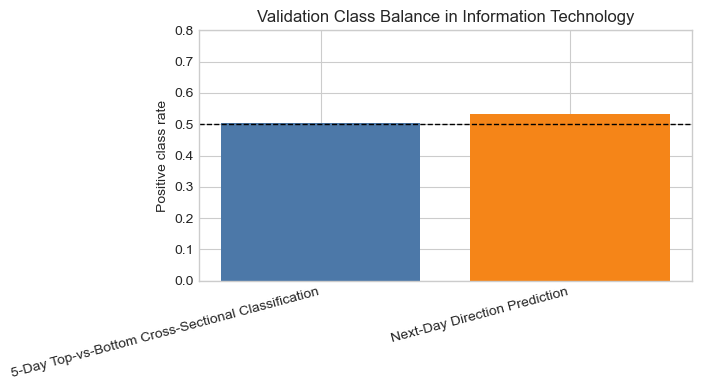

In [6]:
balance_rows = []
for task_name, target_col in TASKS.items():
    valid_subset = tech_data[(tech_data["split"].eq("validation")) & tech_data[target_col].notna()]
    balance_rows.append({
        "Task": task_name,
        "Validation rows": len(valid_subset),
        "Positive class rate": valid_subset[target_col].astype(int).mean(),
    })

class_balance = pd.DataFrame(balance_rows)
display(class_balance)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(class_balance["Task"], class_balance["Positive class rate"], color=["#4c78a8", "#f58518"])
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_ylim(0, 0.8)
ax.set_ylabel("Positive class rate")
ax.set_title("Validation Class Balance in Information Technology")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Shared Evaluation Code

ROC AUC is the primary metric because the modeling goal is ranking likely winners above likely losers. F1 is secondary and helps interpret thresholded predictions.

In [7]:
def metric_dict(y_true, pred, prob):
    return {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, prob),
    }


def prepare_split(source, target_col, split_name):
    subset = source[(source["split"].eq(split_name)) & source[target_col].notna()].copy()
    subset[target_col] = subset[target_col].astype(int)
    return subset.dropna(subset=FINAL_FEATURES)


def evaluate_model(model, train_df, eval_df, target_col):
    model.fit(train_df[FINAL_FEATURES], train_df[target_col].astype(int))
    pred = model.predict(eval_df[FINAL_FEATURES])
    prob = model.predict_proba(eval_df[FINAL_FEATURES])[:, 1]
    return metric_dict(eval_df[target_col].astype(int), pred, prob)


def format_metrics(table):
    out = table.copy()
    for col in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        if col in out:
            out[col] = out[col].map(lambda x: f"{x:.4f}")
    return out

## 4. Dataset Signal Discovery

This compact validation check compares the full panel with the final Information Technology dataset using the same fixed feature set and model class.

,Dataset,Task,Train rows,Validation rows,accuracy,precision,recall,f1,roc_auc
0,All Data,5-Day Top-vs-Bottom Cross-Sectional Classifica...,184023,75491,0.5007,0.5007,0.5256,0.5128,0.5028
2,Information Technology,5-Day Top-vs-Bottom Cross-Sectional Classifica...,27009,11073,0.4836,0.4924,0.7121,0.5822,0.4905
3,Information Technology,Next-Day Direction Prediction,41888,17085,0.5008,0.5280,0.5841,0.5546,0.5019
1,All Data,Next-Day Direction Prediction,306183,125333,0.5098,0.5269,0.7277,0.6112,0.4938


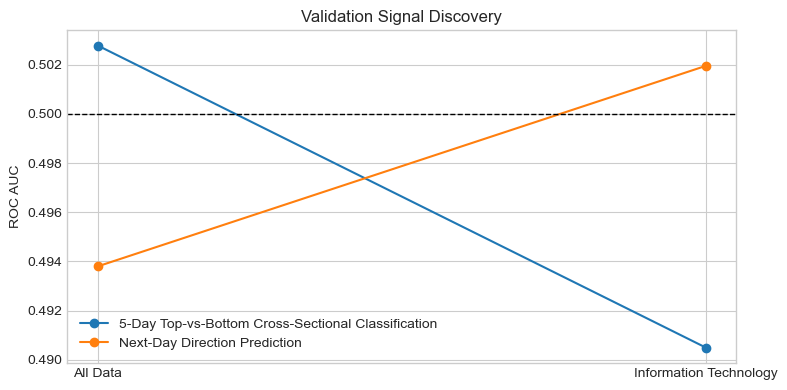

In [8]:
dataset_variants = {
    "All Data": df,
    "Information Technology": tech_data,
}

signal_rows = []
for dataset_name, source in dataset_variants.items():
    for task_name, target_col in TASKS.items():
        train_part = prepare_split(source, target_col, "train")
        valid_part = prepare_split(source, target_col, "validation")
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=42)),
        ])
        metrics = evaluate_model(model, train_part, valid_part, target_col)
        signal_rows.append({
            "Dataset": dataset_name,
            "Task": task_name,
            "Train rows": len(train_part),
            "Validation rows": len(valid_part),
            **metrics,
        })

signal_results = pd.DataFrame(signal_rows)
display(format_metrics(signal_results.sort_values(["Task", "roc_auc"], ascending=[True, False])))

fig, ax = plt.subplots(figsize=(8, 4))
for task_name, group in signal_results.groupby("Task"):
    ax.plot(group["Dataset"], group["roc_auc"], marker="o", label=task_name)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_title("Validation Signal Discovery")
ax.set_ylabel("ROC AUC")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Always Predict Up Baseline

The constant positive-class baseline helps show why F1 can be misleading. A model can have high recall and sometimes high F1 while having ROC AUC of 0.50, meaning no ranking skill.

In [9]:
baseline_rows = []
for task_name, target_col in TASKS.items():
    train_part = prepare_split(tech_data, target_col, "train")
    valid_part = prepare_split(tech_data, target_col, "validation")
    model = DummyClassifier(strategy="constant", constant=1)
    metrics = evaluate_model(model, train_part, valid_part, target_col)
    baseline_rows.append({
        "Task": task_name,
        "Model": "Always Predict Up",
        "Params": "{'constant': 1}",
        "Train rows": len(train_part),
        "Validation rows": len(valid_part),
        **metrics,
    })

always_up_validation = pd.DataFrame(baseline_rows)
display(format_metrics(always_up_validation))

,Task,Model,Params,Train rows,Validation rows,accuracy,precision,recall,f1,roc_auc
0,5-Day Top-vs-Bottom Cross-Sectional Classifica...,Always Predict Up,{'constant': 1},27009,11073,0.5053,0.5053,1.0000,0.6713,0.5000
1,Next-Day Direction Prediction,Always Predict Up,{'constant': 1},41888,17085,0.5322,0.5322,1.0000,0.6947,0.5000


## 6. Logistic Regression with Validation Tuning

Logistic Regression is the primary interpretable baseline. Features are scaled, and hyperparameters are selected using validation ROC AUC.

In [10]:
logistic_grid = [
    {"C": 0.1, "class_weight": None},
    {"C": 0.3, "class_weight": None},
    {"C": 1.0, "class_weight": None},
    {"C": 3.0, "class_weight": None},
    {"C": 1.0, "class_weight": "balanced"},
]

logistic_rows = []
for task_name, target_col in TASKS.items():
    train_part = prepare_split(tech_data, target_col, "train")
    valid_part = prepare_split(tech_data, target_col, "validation")
    for params in logistic_grid:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=42, **params)),
        ])
        metrics = evaluate_model(model, train_part, valid_part, target_col)
        logistic_rows.append({
            "Task": task_name,
            "Model": "Logistic Regression",
            "Params": str(params),
            "Train rows": len(train_part),
            "Validation rows": len(valid_part),
            **metrics,
        })

logistic_validation = pd.DataFrame(logistic_rows)
display(format_metrics(logistic_validation.sort_values(["Task", "roc_auc"], ascending=[True, False])))
best_logistic = logistic_validation.sort_values(["Task", "roc_auc"], ascending=[True, False]).groupby("Task").head(1)

,Task,Model,Params,Train rows,Validation rows,accuracy,precision,recall,f1,roc_auc
0,5-Day Top-vs-Bottom Cross-Sectional Classifica...,Logistic Regression,"{'C': 0.1, 'class_weight': None}",27009,11073,0.4853,0.4937,0.7231,0.5868,0.4934
3,5-Day Top-vs-Bottom Cross-Sectional Classifica...,Logistic Regression,"{'C': 3.0, 'class_weight': None}",27009,11073,0.4851,0.4934,0.7097,0.5821,0.4911
4,5-Day Top-vs-Bottom Cross-Sectional Classifica...,Logistic Regression,"{'C': 1.0, 'class_weight': 'balanced'}",27009,11073,0.4988,0.5035,0.5816,0.5397,0.4910
1,5-Day Top-vs-Bottom Cross-Sectional Classifica...,Logistic Regression,"{'C': 0.3, 'class_weight': None}",27009,11073,0.4840,0.4927,0.7167,0.5840,0.4909
2,5-Day Top-vs-Bottom Cross-Sectional Classifica...,Logistic Regression,"{'C': 1.0, 'class_weight': None}",27009,11073,0.4836,0.4924,0.7121,0.5822,0.4905
5,Next-Day Direction Prediction,Logistic Regression,"{'C': 0.1, 'class_weight': None}",41888,17085,0.5032,0.5296,0.5957,0.5607,0.5036
6,Next-Day Direction Prediction,Logistic Regression,"{'C': 0.3, 'class_weight': None}",41888,17085,0.5018,0.5287,0.5878,0.5567,0.5024
7,Next-Day Direction Prediction,Logistic Regression,"{'C': 1.0, 'class_weight': None}",41888,17085,0.5008,0.5280,0.5841,0.5546,0.5019
8,Next-Day Direction Prediction,Logistic Regression,"{'C': 3.0, 'class_weight': None}",41888,17085,0.5005,0.5278,0.5836,0.5543,0.5018
9,Next-Day Direction Prediction,Logistic Regression,"{'C': 1.0, 'class_weight': 'balanced'}",41888,17085,0.4983,0.5354,0.4342,0.4795,0.5017


## 7. Gradient Boosting with Validation Tuning

Gradient Boosting is the tree-based comparison model. The grid is compact to keep the search controlled and interpretable.

In [11]:
gb_grid = [
    {"n_estimators": 50, "learning_rate": 0.10, "max_depth": 2, "min_samples_leaf": 25, "subsample": 0.8},
    {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 2, "min_samples_leaf": 25, "subsample": 0.9},
    {"n_estimators": 150, "learning_rate": 0.03, "max_depth": 2, "min_samples_leaf": 50, "subsample": 0.8},
    {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 3, "min_samples_leaf": 50, "subsample": 0.8},
]

gb_rows = []
for task_name, target_col in TASKS.items():
    train_part = prepare_split(tech_data, target_col, "train")
    valid_part = prepare_split(tech_data, target_col, "validation")
    for params in gb_grid:
        model = GradientBoostingClassifier(random_state=42, **params)
        metrics = evaluate_model(model, train_part, valid_part, target_col)
        gb_rows.append({
            "Task": task_name,
            "Model": "Gradient Boosting",
            "Params": str(params),
            "Train rows": len(train_part),
            "Validation rows": len(valid_part),
            **metrics,
        })

gb_validation = pd.DataFrame(gb_rows)
display(format_metrics(gb_validation.sort_values(["Task", "roc_auc"], ascending=[True, False])))
best_gb = gb_validation.sort_values(["Task", "roc_auc"], ascending=[True, False]).groupby("Task").head(1)

,Task,Model,Params,Train rows,Validation rows,accuracy,precision,recall,f1,roc_auc
0,5-Day Top-vs-Bottom Cross-Sectional Classifica...,Gradient Boosting,"{'n_estimators': 50, 'learning_rate': 0.1, 'ma...",27009,11073,0.4898,0.4969,0.7702,0.6041,0.4821
2,5-Day Top-vs-Bottom Cross-Sectional Classifica...,Gradient Boosting,"{'n_estimators': 150, 'learning_rate': 0.03, '...",27009,11073,0.4798,0.4905,0.7596,0.5961,0.4765
3,5-Day Top-vs-Bottom Cross-Sectional Classifica...,Gradient Boosting,"{'n_estimators': 100, 'learning_rate': 0.05, '...",27009,11073,0.4814,0.4906,0.6851,0.5717,0.4759
1,5-Day Top-vs-Bottom Cross-Sectional Classifica...,Gradient Boosting,"{'n_estimators': 100, 'learning_rate': 0.05, '...",27009,11073,0.4776,0.4893,0.7712,0.5987,0.4744
5,Next-Day Direction Prediction,Gradient Boosting,"{'n_estimators': 100, 'learning_rate': 0.05, '...",41888,17085,0.5117,0.5276,0.7880,0.6320,0.5053
7,Next-Day Direction Prediction,Gradient Boosting,"{'n_estimators': 100, 'learning_rate': 0.05, '...",41888,17085,0.5144,0.5321,0.7266,0.6143,0.5025
4,Next-Day Direction Prediction,Gradient Boosting,"{'n_estimators': 50, 'learning_rate': 0.1, 'ma...",41888,17085,0.5141,0.5282,0.8145,0.6409,0.5006
6,Next-Day Direction Prediction,Gradient Boosting,"{'n_estimators': 150, 'learning_rate': 0.03, '...",41888,17085,0.5128,0.5266,0.8380,0.6467,0.4946


## 8. LSTM with Modest Validation Tuning

The LSTM uses uninterrupted ticker-level sequences from the Information Technology sector. Scaling is fit on training rows only during validation tuning.

In [12]:
if torch is None:
    raise ImportError("PyTorch is required for the LSTM section.")

torch.manual_seed(42)
np.random.seed(42)
torch.set_num_threads(1)


def make_sequences(source, target_col, seq_len, allowed_splits, label_splits, scaler):
    scaled = source[source[target_col].notna()].copy()
    scaled[target_col] = scaled[target_col].astype(int)
    scaled[FINAL_FEATURES] = scaler.transform(scaled[FINAL_FEATURES])

    xs, ys = [], []
    allowed_splits = set(allowed_splits)
    if isinstance(label_splits, str):
        label_splits = {label_splits}
    else:
        label_splits = set(label_splits)
    for _, group in scaled.groupby("ticker", sort=False):
        group = group.sort_values("date")
        values = group[FINAL_FEATURES].to_numpy(dtype=np.float32)
        labels = group[target_col].to_numpy(dtype=np.float32)
        splits = group["split"].to_numpy()
        for i in range(seq_len - 1, len(group)):
            if splits[i] not in label_splits:
                continue
            if not set(splits[i - seq_len + 1 : i + 1]).issubset(allowed_splits):
                continue
            xs.append(values[i - seq_len + 1 : i + 1])
            ys.append(labels[i])
    return np.asarray(xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)


class SmallLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=layers,
            dropout=dropout if layers > 1 else 0.0,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.lstm(x)
        return self.out(self.dropout(output[:, -1, :])).squeeze(1)


def train_lstm_for_epochs(train_x, train_y, config, epochs):
    model = SmallLSTM(train_x.shape[2], config["hidden_size"], config["layers"], config["dropout"])
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"], weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss()
    loader = DataLoader(
        TensorDataset(torch.tensor(train_x), torch.tensor(train_y)),
        batch_size=config["batch_size"],
        shuffle=True,
    )
    for _ in range(epochs):
        model.train()
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
    return model


def predict_lstm(model, eval_x, batch_size):
    model.eval()
    probs = []
    loader = DataLoader(TensorDataset(torch.tensor(eval_x)), batch_size=batch_size)
    with torch.no_grad():
        for (batch_x,) in loader:
            probs.append(torch.sigmoid(model(batch_x)).numpy())
    return np.concatenate(probs)


def tune_lstm(train_x, train_y, valid_x, valid_y, config):
    best_auc, best_f1, best_epoch = -1, 0, 0
    patience, misses = 4, 0
    model = SmallLSTM(train_x.shape[2], config["hidden_size"], config["layers"], config["dropout"])
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"], weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss()
    loader = DataLoader(
        TensorDataset(torch.tensor(train_x), torch.tensor(train_y)),
        batch_size=config["batch_size"],
        shuffle=True,
    )

    for epoch in range(1, 31):
        model.train()
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        probs = predict_lstm(model, valid_x, config["batch_size"])
        preds = (probs >= 0.5).astype(int)
        auc = roc_auc_score(valid_y, probs)
        f1 = f1_score(valid_y, preds, zero_division=0)
        if auc > best_auc:
            best_auc, best_f1, best_epoch = auc, f1, epoch
            misses = 0
        else:
            misses += 1
            if misses >= patience:
                break
    return {"roc_auc": best_auc, "f1": best_f1, "best_epoch": best_epoch}


lstm_grid = [
    {"seq_len": 5, "hidden_size": 32, "layers": 1, "dropout": 0.0, "lr": 0.001, "batch_size": 64},
    {"seq_len": 5, "hidden_size": 64, "layers": 2, "dropout": 0.2, "lr": 0.0005, "batch_size": 128},
    {"seq_len": 10, "hidden_size": 32, "layers": 2, "dropout": 0.2, "lr": 0.0005, "batch_size": 128},
    {"seq_len": 10, "hidden_size": 64, "layers": 2, "dropout": 0.2, "lr": 0.0005, "batch_size": 128},
]

lstm_rows = []
for task_name, target_col in TASKS.items():
    train_part = prepare_split(tech_data, target_col, "train")
    scaler = StandardScaler().fit(train_part[FINAL_FEATURES])
    for config in lstm_grid:
        train_x, train_y = make_sequences(tech_data, target_col, config["seq_len"], ["train"], "train", scaler)
        valid_x, valid_y = make_sequences(tech_data, target_col, config["seq_len"], ["validation"], "validation", scaler)
        metrics = tune_lstm(train_x, train_y, valid_x, valid_y, config)
        lstm_rows.append({
            "Task": task_name,
            "Model": "LSTM",
            "Params": str(config),
            "Best epoch": metrics["best_epoch"],
            "Train rows": len(train_x),
            "Validation rows": len(valid_x),
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"],
        })

lstm_validation = pd.DataFrame(lstm_rows)
display(format_metrics(lstm_validation.sort_values(["Task", "roc_auc"], ascending=[True, False])))
best_lstm = lstm_validation.sort_values(["Task", "roc_auc"], ascending=[True, False]).groupby("Task").head(1)

,Task,Model,Params,Best epoch,Train rows,Validation rows,accuracy,precision,recall,f1,roc_auc
2,5-Day Top-vs-Bottom Cross-Sectional Classifica...,LSTM,"{'seq_len': 10, 'hidden_size': 32, 'layers': 2...",1,26397,10452,nan,nan,nan,0.6021,0.5180
1,5-Day Top-vs-Bottom Cross-Sectional Classifica...,LSTM,"{'seq_len': 5, 'hidden_size': 64, 'layers': 2,...",1,26737,10797,nan,nan,nan,0.5631,0.5171
0,5-Day Top-vs-Bottom Cross-Sectional Classifica...,LSTM,"{'seq_len': 5, 'hidden_size': 32, 'layers': 1,...",5,26737,10797,nan,nan,nan,0.4747,0.5159
3,5-Day Top-vs-Bottom Cross-Sectional Classifica...,LSTM,"{'seq_len': 10, 'hidden_size': 64, 'layers': 2...",1,26397,10452,nan,nan,nan,0.5729,0.5105
4,Next-Day Direction Prediction,LSTM,"{'seq_len': 5, 'hidden_size': 32, 'layers': 1,...",5,41616,16809,nan,nan,nan,0.6286,0.5205
5,Next-Day Direction Prediction,LSTM,"{'seq_len': 5, 'hidden_size': 64, 'layers': 2,...",8,41616,16809,nan,nan,nan,0.6402,0.5149
6,Next-Day Direction Prediction,LSTM,"{'seq_len': 10, 'hidden_size': 32, 'layers': 2...",7,41276,16464,nan,nan,nan,0.6603,0.5114
7,Next-Day Direction Prediction,LSTM,"{'seq_len': 10, 'hidden_size': 64, 'layers': 2...",3,41276,16464,nan,nan,nan,0.6644,0.5100


## Validation Model Comparison

The best configuration for each model family is selected by validation ROC AUC.

,Task,Model,Params,Train rows,Validation rows,accuracy,precision,recall,f1,roc_auc,Best epoch
6,5-Day Top-vs-Bottom Cross-Sectional Classifica...,LSTM,"{'seq_len': 10, 'hidden_size': 32, 'layers': 2...",26397,10452,nan,nan,nan,0.6021,0.5180,1.0
0,5-Day Top-vs-Bottom Cross-Sectional Classifica...,Always Predict Up,{'constant': 1},27009,11073,0.5053,0.5053,1.0000,0.6713,0.5000,NaN
2,5-Day Top-vs-Bottom Cross-Sectional Classifica...,Logistic Regression,"{'C': 0.1, 'class_weight': None}",27009,11073,0.4853,0.4937,0.7231,0.5868,0.4934,NaN
4,5-Day Top-vs-Bottom Cross-Sectional Classifica...,Gradient Boosting,"{'n_estimators': 50, 'learning_rate': 0.1, 'ma...",27009,11073,0.4898,0.4969,0.7702,0.6041,0.4821,NaN
7,Next-Day Direction Prediction,LSTM,"{'seq_len': 5, 'hidden_size': 32, 'layers': 1,...",41616,16809,nan,nan,nan,0.6286,0.5205,5.0
5,Next-Day Direction Prediction,Gradient Boosting,"{'n_estimators': 100, 'learning_rate': 0.05, '...",41888,17085,0.5117,0.5276,0.7880,0.6320,0.5053,NaN
3,Next-Day Direction Prediction,Logistic Regression,"{'C': 0.1, 'class_weight': None}",41888,17085,0.5032,0.5296,0.5957,0.5607,0.5036,NaN
1,Next-Day Direction Prediction,Always Predict Up,{'constant': 1},41888,17085,0.5322,0.5322,1.0000,0.6947,0.5000,NaN


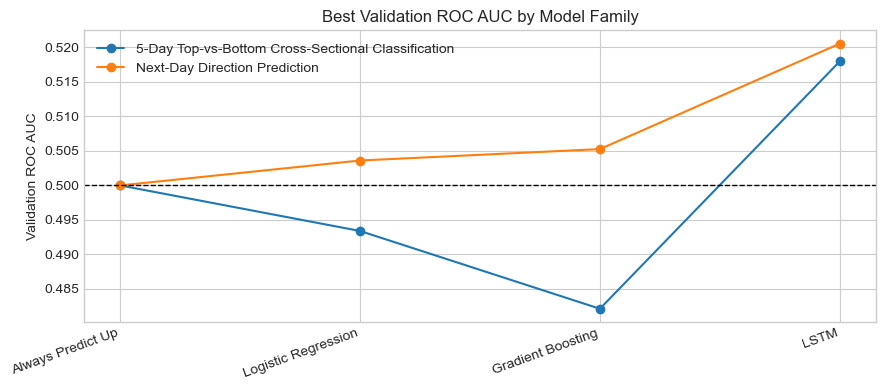

In [13]:
validation_summary = pd.concat([
    always_up_validation,
    best_logistic,
    best_gb,
    best_lstm,
], ignore_index=True)

display(format_metrics(validation_summary.sort_values(["Task", "roc_auc"], ascending=[True, False])))

fig, ax = plt.subplots(figsize=(9, 4))
for task_name, group in validation_summary.groupby("Task"):
    ax.plot(group["Model"], group["roc_auc"], marker="o", label=task_name)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_ylabel("Validation ROC AUC")
ax.set_title("Best Validation ROC AUC by Model Family")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 9. Final Test-Set Comparison

The test set is used only in this section. Tabular models are refit on train + validation after hyperparameters are selected. The LSTM uses the validation-selected configuration and best epoch, then trains on train + validation before test scoring. Test rows are not used for scaling, tuning, or early stopping.

In [14]:
def selected_params(summary, task_name, model_name):
    row = summary[(summary["Task"].eq(task_name)) & (summary["Model"].eq(model_name))].iloc[0]
    return ast.literal_eval(row["Params"])


final_rows = []
for task_name, target_col in TASKS.items():
    train_valid = tech_data[
        tech_data["split"].isin(["train", "validation"]) & tech_data[target_col].notna()
    ].copy()
    train_valid[target_col] = train_valid[target_col].astype(int)
    test_part = prepare_split(tech_data, target_col, "test")

    model = DummyClassifier(strategy="constant", constant=1)
    metrics = evaluate_model(model, train_valid, test_part, target_col)
    final_rows.append({"Task": task_name, "Model": "Always Predict Up", **metrics})

    lr_params = selected_params(validation_summary, task_name, "Logistic Regression")
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42, **lr_params)),
    ])
    metrics = evaluate_model(model, train_valid, test_part, target_col)
    final_rows.append({"Task": task_name, "Model": "Logistic Regression", **metrics})

    gb_params = selected_params(validation_summary, task_name, "Gradient Boosting")
    model = GradientBoostingClassifier(random_state=42, **gb_params)
    metrics = evaluate_model(model, train_valid, test_part, target_col)
    final_rows.append({"Task": task_name, "Model": "Gradient Boosting", **metrics})

    lstm_params = selected_params(validation_summary, task_name, "LSTM")
    lstm_epoch = int(validation_summary[
        validation_summary["Task"].eq(task_name) & validation_summary["Model"].eq("LSTM")
    ].iloc[0]["Best epoch"])
    scaler = StandardScaler().fit(train_valid[FINAL_FEATURES])
    train_x, train_y = make_sequences(
        tech_data,
        target_col,
        lstm_params["seq_len"],
        ["train", "validation"],
        ["train", "validation"],
        scaler,
    )
    test_x, test_y = make_sequences(tech_data, target_col, lstm_params["seq_len"], ["test"], "test", scaler)
    model = train_lstm_for_epochs(train_x, train_y, lstm_params, max(lstm_epoch, 1))
    probs = predict_lstm(model, test_x, lstm_params["batch_size"])
    preds = (probs >= 0.5).astype(int)
    metrics = metric_dict(test_y, preds, probs)
    final_rows.append({"Task": task_name, "Model": "LSTM", **metrics})

test_results = pd.DataFrame(final_rows)
display(format_metrics(test_results.sort_values(["Task", "roc_auc"], ascending=[True, False])))

,Task,Model,accuracy,precision,recall,f1,roc_auc
0,5-Day Top-vs-Bottom Cross-Sectional Classifica...,Always Predict Up,0.4848,0.4848,1.0000,0.6530,0.5000
3,5-Day Top-vs-Bottom Cross-Sectional Classifica...,LSTM,0.5036,0.4907,0.6151,0.5459,0.4967
2,5-Day Top-vs-Bottom Cross-Sectional Classifica...,Gradient Boosting,0.4743,0.4683,0.6244,0.5352,0.4874
1,5-Day Top-vs-Bottom Cross-Sectional Classifica...,Logistic Regression,0.4706,0.4508,0.4218,0.4359,0.4592
4,Next-Day Direction Prediction,Always Predict Up,0.5173,0.5173,1.0000,0.6819,0.5000
5,Next-Day Direction Prediction,Logistic Regression,0.5101,0.5156,0.8789,0.6499,0.4945
7,Next-Day Direction Prediction,LSTM,0.5028,0.5113,0.8281,0.6322,0.4928
6,Next-Day Direction Prediction,Gradient Boosting,0.5191,0.5189,0.9661,0.6752,0.4902


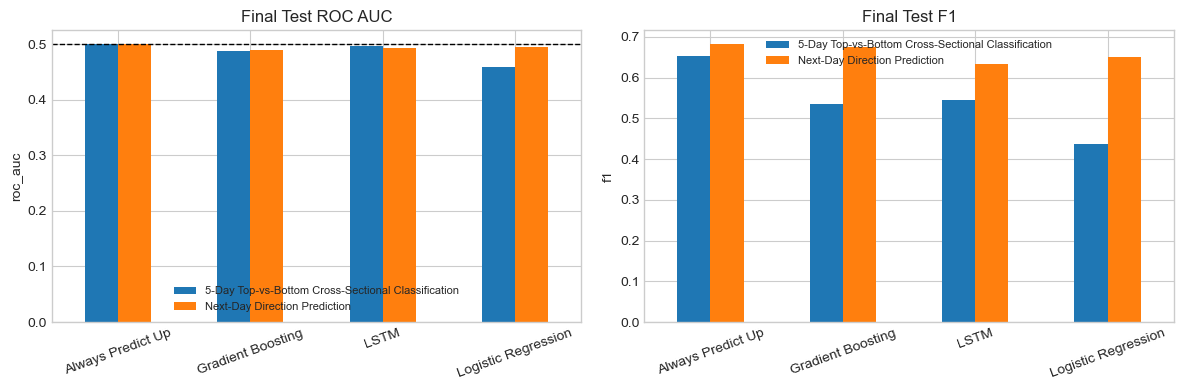

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for ax, metric, title in zip(axes, ["roc_auc", "f1"], ["Final Test ROC AUC", "Final Test F1"]):
    pivot = test_results.pivot(index="Model", columns="Task", values=metric)
    pivot.plot(kind="bar", ax=ax)
    if metric == "roc_auc":
        ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_xlabel("")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()